# Interaction NN Diagnostics: Information vs. Optimization Bottleneck

The simulation study (`interaction_study.ipynb`) shows the Interaction NN breaks the linearity barrier
(e.g. R²≈0.25 vs Linear PRS R²≈0.14 at 75% nonlinear DGP), but it only closes ~25% of the gap to the
Oracle NN (R²≈0.42). This notebook diagnoses **why** via four analyses:

- **H1 (optimization bottleneck):** The Gamma signal contains enough information, but the optimizer gets stuck.
- **H2 (information bottleneck):** The Gamma matrix genuinely doesn't contain enough information.

**Analyses:**
1. Oracle parameters evaluated through the Interaction loss
2. Spectral analysis of Gamma
3. Spectral initialization experiment
4. Multi-start experiment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from ssnn.simulation import (
    SimulationScenario,
    generate_maf_spectrum,
    generate_binomial_genotypes,
    generate_effect_sizes,
    compute_summary_stats_from_genotypes,
    train_oracle_nn,
    _calibrate_gamma,
)
from ssnn.optimizer import train
from ssnn.interaction_optimizer import train_interaction
from ssnn.interaction_risk import compute_interaction_loss
from ssnn.utils import (
    generate_ld_matrix,
    linear_prs_weights,
    nn_predict,
    nn_prediction_r2,
    prediction_r2,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

SEED = 42
P = 30
M = 5
N_TRAIN = 5000
N_TEST = 2000
NONLINEAR_FRAC = 0.50
HERITABILITY = 0.5
SPARSITY = 0.3
LD_DECAY = 0.5
MAF_SPECTRUM = "mixed"
ACTIVATION = "relu"
INTERACTION_MAX_ITERS = 2000
ORACLE_MAX_ITERS = 5000

## Helper: Generate a single DGP replicate

We replicate the data-generation portion of `run_single_rep` so that we have
direct access to **all** intermediate quantities: `X_train`, `y_train`, `X_test`,
`y_test`, `Sigma`, `Sigma_beta_hat`, `E_y2_hat`, `Gamma_hat`, `beta_star`, `w_star`, `gamma`.

In [2]:
def generate_replicate(seed):
    """Generate one full replicate, returning all intermediate data."""
    rng = np.random.default_rng(seed)

    maf = generate_maf_spectrum(P, MAF_SPECTRUM, rng)
    Sigma = generate_ld_matrix(P, decay=LD_DECAY)
    beta_star, sigma_eps = generate_effect_sizes(P, Sigma, HERITABILITY, SPARSITY, rng)

    X_train_raw = generate_binomial_genotypes(N_TRAIN, maf, Sigma, rng)
    X_test_raw = generate_binomial_genotypes(N_TEST, maf, Sigma, rng)

    train_means = X_train_raw.mean(axis=0)
    X_train = X_train_raw - train_means
    X_test = X_test_raw - train_means

    w_star = rng.standard_normal(P) * 0.3
    gamma_coeff = _calibrate_gamma(X_train, beta_star, w_star, NONLINEAR_FRAC)

    var_linear = np.var(X_train @ beta_star)
    var_nonlinear = np.var(gamma_coeff * np.maximum(0.0, X_train @ w_star))
    total_genetic_var = var_linear + var_nonlinear
    sigma_eps = float(np.sqrt(total_genetic_var * (1 - HERITABILITY) / HERITABILITY))

    y_train = (
        X_train @ beta_star
        + gamma_coeff * np.maximum(0.0, X_train @ w_star)
        + rng.normal(0, sigma_eps, N_TRAIN)
    )
    y_test = (
        X_test @ beta_star
        + gamma_coeff * np.maximum(0.0, X_test @ w_star)
        + rng.normal(0, sigma_eps, N_TEST)
    )

    stats = compute_summary_stats_from_genotypes(X_train_raw, y_train, Sigma)

    return {
        "rng": rng,
        "maf": maf,
        "Sigma": Sigma,
        "beta_star": beta_star,
        "sigma_eps": sigma_eps,
        "w_star": w_star,
        "gamma_coeff": gamma_coeff,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "Sigma_beta_hat": stats["Sigma_beta_hat"],
        "E_y2_hat": stats["E_y2_hat"],
        "Gamma_hat": stats["Gamma_hat"],
        "maf_hat": stats["maf"],
    }

## 1. Oracle Parameters Through the Interaction Loss

For a single replicate, we:
1. Train the Interaction NN normally (warm-started from Gaussian solution).
2. Train the Oracle NN on individual-level data.
3. Evaluate the Interaction loss at both parameter sets.

**Interpretation:**
- If the Oracle's (a, W) achieve a **much lower** interaction loss → **H1 (optimization bottleneck)**.
- If the Oracle's loss is similar or higher → **H2 (information bottleneck)** — the Interaction loss surface
  doesn't "see" the Oracle's solution as better.

In [3]:
data = generate_replicate(SEED)

gauss_result = train(
    data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"],
    m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
    init_scale=0.01, rng=np.random.default_rng(100),
)

int_result = train_interaction(
    data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"], data["Gamma_hat"],
    m=M, activation=ACTIVATION, lr=0.005, max_iters=INTERACTION_MAX_ITERS,
    rng=np.random.default_rng(200),
    grad_clip=0.5, max_backtracks=10,
    a_init=gauss_result.a, W_init=gauss_result.W,
)

oracle_a, oracle_W, oracle_loss_hist = train_oracle_nn(
    data["X_train"], data["y_train"],
    m=M, activation=ACTIVATION, lr=0.01,
    max_iters=ORACLE_MAX_ITERS, batch_size=256,
    rng=np.random.default_rng(300),
)

int_loss_at_int_params = compute_interaction_loss(
    int_result.a, int_result.W,
    data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"],
    data["Gamma_hat"], ACTIVATION,
)
int_loss_at_oracle_params = compute_interaction_loss(
    oracle_a, oracle_W,
    data["Sigma"], data["Sigma_beta_hat"], data["E_y2_hat"],
    data["Gamma_hat"], ACTIVATION,
)

r2_int = nn_prediction_r2(data["X_test"], data["y_test"], int_result.a, int_result.W, ACTIVATION)
r2_oracle = nn_prediction_r2(data["X_test"], data["y_test"], oracle_a, oracle_W, ACTIVATION)

print("=" * 60)
print("Analysis 1: Oracle params through the Interaction loss")
print("=" * 60)
print(f"{'':30s} {'Int. Loss':>12s} {'Test R²':>10s}")
print("-" * 54)
print(f"{'Interaction NN (trained)':30s} {int_loss_at_int_params:12.6f} {r2_int:10.4f}")
print(f"{'Oracle NN params → Int. loss':30s} {int_loss_at_oracle_params:12.6f} {r2_oracle:10.4f}")
print()
if int_loss_at_oracle_params < int_loss_at_int_params * 0.9:
    print("→ Oracle params achieve SIGNIFICANTLY LOWER interaction loss.")
    print("  This supports H1 (optimization bottleneck).")
else:
    print("→ Oracle params do NOT achieve a significantly lower interaction loss.")
    print("  This supports H2 (information bottleneck): Gamma doesn't see the Oracle solution as better.")

Analysis 1: Oracle params through the Interaction loss
                                  Int. Loss    Test R²
------------------------------------------------------
Interaction NN (trained)           4.141953     0.3288
Oracle NN params → Int. loss      10.250010     0.5338

→ Oracle params do NOT achieve a significantly lower interaction loss.
  This supports H2 (information bottleneck): Gamma doesn't see the Oracle solution as better.


## 2. Spectral Analysis of Gamma

We compute the eigendecomposition of `Gamma_hat` and compare the leading eigenvectors to the
true nonlinear direction `w*` (cosine similarity). We also compute a theoretical Gamma using a
large Monte Carlo sample and compare eigenstructures.

**Interpretation:**
- If the leading eigenvector of Gamma aligns well with w* → the signal is detectable.
- If it doesn't → the nonlinear signal is buried in noise (supports H2).
- Comparing Gamma_hat vs Gamma_theoretical separates finite-sample noise from fundamental limitations.

In [4]:
Gamma_hat = data["Gamma_hat"]
w_star = data["w_star"]
Sigma = data["Sigma"]

evals_hat, evecs_hat = np.linalg.eigh(Gamma_hat)
order = np.argsort(np.abs(evals_hat))[::-1]
evals_hat = evals_hat[order]
evecs_hat = evecs_hat[:, order]

w_star_normed = w_star / np.linalg.norm(w_star)

print("=" * 60)
print("Analysis 2: Spectral analysis of Gamma")
print("=" * 60)
print()
print("--- Gamma_hat eigenvalue spectrum ---")
print(f"{'Rank':>6s} {'Eigenvalue':>12s} {'|cos(evec, w*)|':>18s}")
print("-" * 38)
for i in range(min(10, P)):
    cos_sim = abs(float(evecs_hat[:, i] @ w_star_normed))
    print(f"{i+1:6d} {evals_hat[i]:12.6f} {cos_sim:18.4f}")

Analysis 2: Spectral analysis of Gamma

--- Gamma_hat eigenvalue spectrum ---
  Rank   Eigenvalue    |cos(evec, w*)|
--------------------------------------
     1     1.049201             0.4802
     2     0.529499             0.3925
     3     0.422136             0.0047
     4     0.387941             0.0583
     5     0.363561             0.0336
     6     0.351810             0.0493
     7     0.299444             0.1127
     8     0.273285             0.3226
     9     0.257348             0.2884
    10     0.252067             0.1550


In [5]:
N_MC = 200000
rng_mc = np.random.default_rng(999)

X_mc = generate_binomial_genotypes(N_MC, data["maf"], Sigma, rng_mc)
train_means_mc = X_mc.mean(axis=0)
X_mc_centered = X_mc - train_means_mc

y_mc = (
    X_mc_centered @ data["beta_star"]
    + data["gamma_coeff"] * np.maximum(0.0, X_mc_centered @ w_star)
    + rng_mc.normal(0, data["sigma_eps"], N_MC)
)
Gamma_theoretical = X_mc_centered.T @ (X_mc_centered * y_mc[:, None]) / N_MC

evals_theo, evecs_theo = np.linalg.eigh(Gamma_theoretical)
order_theo = np.argsort(np.abs(evals_theo))[::-1]
evals_theo = evals_theo[order_theo]
evecs_theo = evecs_theo[:, order_theo]

print()
print("--- Gamma_theoretical (N=200k MC) eigenvalue spectrum ---")
print(f"{'Rank':>6s} {'Eigenvalue':>12s} {'|cos(evec, w*)|':>18s}")
print("-" * 38)
for i in range(min(10, P)):
    cos_sim = abs(float(evecs_theo[:, i] @ w_star_normed))
    print(f"{i+1:6d} {evals_theo[i]:12.6f} {cos_sim:18.4f}")


--- Gamma_theoretical (N=200k MC) eigenvalue spectrum ---
  Rank   Eigenvalue    |cos(evec, w*)|
--------------------------------------
     1     0.975107             0.4886
     2     0.465247             0.3794
     3     0.405058             0.0109
     4     0.367542             0.0605
     5     0.356364             0.0266
     6     0.328696             0.1100
     7     0.274130             0.1704
     8     0.243341             0.1666
     9     0.225058             0.2964
    10     0.204992             0.1322


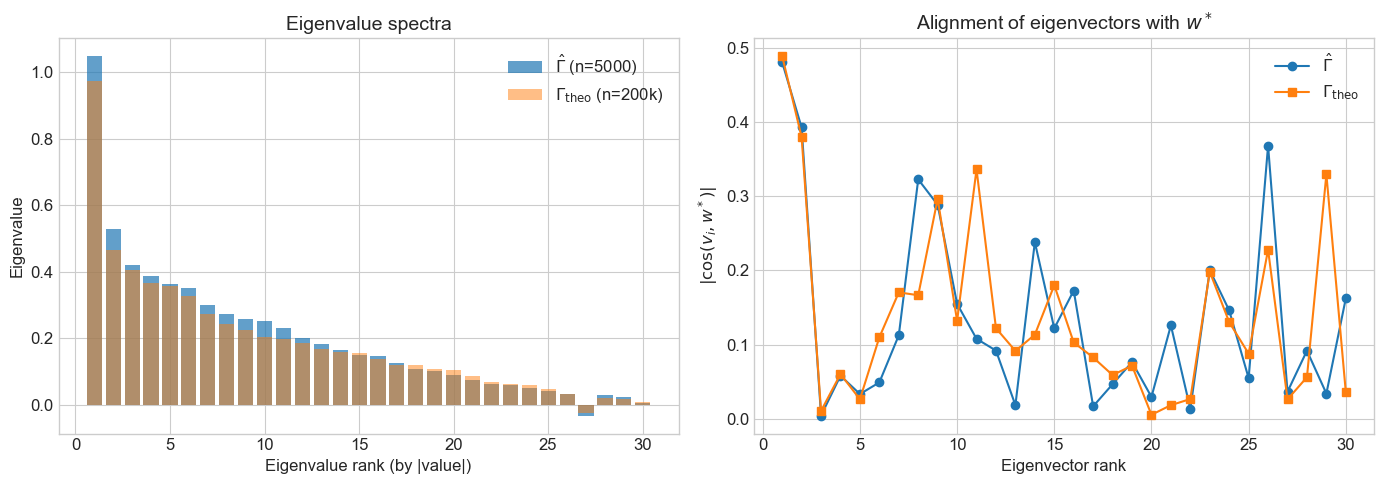


Best |cos(evec, w*)| for Gamma_hat:         0.4802
Best |cos(evec, w*)| for Gamma_theoretical:  0.4886

→ w* is NOT well-aligned even with Gamma_theoretical (200k samples).
  Fundamental limitation: Gamma doesn't encode w* well (strong H2).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, P + 1), evals_hat, alpha=0.7, label=r"$\hat{\Gamma}$ (n=5000)")
axes[0].bar(range(1, P + 1), evals_theo, alpha=0.5, label=r"$\Gamma_{\rm theo}$ (n=200k)")
axes[0].set_xlabel("Eigenvalue rank (by |value|)")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Eigenvalue spectra")
axes[0].legend()

cos_hat = [abs(float(evecs_hat[:, i] @ w_star_normed)) for i in range(P)]
cos_theo = [abs(float(evecs_theo[:, i] @ w_star_normed)) for i in range(P)]
axes[1].plot(range(1, P + 1), cos_hat, 'o-', label=r"$\hat{\Gamma}$")
axes[1].plot(range(1, P + 1), cos_theo, 's-', label=r"$\Gamma_{\rm theo}$")
axes[1].set_xlabel("Eigenvector rank")
axes[1].set_ylabel(r"$|\cos(v_i, w^*)|$")
axes[1].set_title(r"Alignment of eigenvectors with $w^*$")
axes[1].legend()

plt.tight_layout()
plt.show()

best_hat = max(cos_hat)
best_theo = max(cos_theo)
print(f"\nBest |cos(evec, w*)| for Gamma_hat:         {best_hat:.4f}")
print(f"Best |cos(evec, w*)| for Gamma_theoretical:  {best_theo:.4f}")
print()
if best_theo > 0.7:
    if best_hat > 0.5:
        print("→ w* IS detectable in both Gamma_hat and Gamma_theoretical.")
        print("  The signal is present; any remaining gap likely reflects optimization difficulty (H1).")
    else:
        print("→ w* is detectable in Gamma_theoretical but NOT in Gamma_hat.")
        print("  Finite-sample noise washes out the signal. Partial H2 (sample-size bottleneck).")
else:
    print("→ w* is NOT well-aligned even with Gamma_theoretical (200k samples).")
    print("  Fundamental limitation: Gamma doesn't encode w* well (strong H2).")

## 3. Spectral Initialization Experiment

Instead of warm-starting from the Gaussian solution, we initialize **one** hidden unit's weights
from the leading eigenvector of `Gamma_hat` and the rest randomly. We then train with `train_interaction`
and compare test R² against the standard warm-start across 10 seeds.

**Interpretation:**
- If spectral init consistently outperforms warm-start → warm-start initialization is suboptimal (H1).
- If no improvement → the initialization isn't the bottleneck.

In [7]:
N_SEEDS = 10
results_warmstart = []
results_spectral = []

for seed_i in range(N_SEEDS):
    rep_data = generate_replicate(500 + seed_i)

    gauss_res = train(
        rep_data["Sigma"], rep_data["Sigma_beta_hat"], rep_data["E_y2_hat"],
        m=M, activation=ACTIVATION, lr=0.01, max_iters=3000,
        init_scale=0.01, rng=np.random.default_rng(1000 + seed_i),
    )

    int_ws = train_interaction(
        rep_data["Sigma"], rep_data["Sigma_beta_hat"], rep_data["E_y2_hat"],
        rep_data["Gamma_hat"],
        m=M, activation=ACTIVATION, lr=0.005, max_iters=INTERACTION_MAX_ITERS,
        rng=np.random.default_rng(2000 + seed_i),
        grad_clip=0.5, max_backtracks=10,
        a_init=gauss_res.a, W_init=gauss_res.W,
    )
    r2_ws = nn_prediction_r2(
        rep_data["X_test"], rep_data["y_test"],
        int_ws.a, int_ws.W, ACTIVATION,
    )
    results_warmstart.append(r2_ws)

    evals_local, evecs_local = np.linalg.eigh(rep_data["Gamma_hat"])
    lead_idx = np.argmax(np.abs(evals_local))
    lead_evec = evecs_local[:, lead_idx]

    rng_spec = np.random.default_rng(3000 + seed_i)
    W_spec = rng_spec.standard_normal((M, P)) * 0.01
    a_spec = rng_spec.standard_normal(M) * 0.01
    W_spec[0, :] = lead_evec * 0.1

    int_spec = train_interaction(
        rep_data["Sigma"], rep_data["Sigma_beta_hat"], rep_data["E_y2_hat"],
        rep_data["Gamma_hat"],
        m=M, activation=ACTIVATION, lr=0.005, max_iters=INTERACTION_MAX_ITERS,
        rng=np.random.default_rng(4000 + seed_i),
        grad_clip=0.5, max_backtracks=10,
        a_init=a_spec, W_init=W_spec,
    )
    r2_spec = nn_prediction_r2(
        rep_data["X_test"], rep_data["y_test"],
        int_spec.a, int_spec.W, ACTIVATION,
    )
    results_spectral.append(r2_spec)

    print(f"  Seed {seed_i}: warm-start R²={r2_ws:.4f}, spectral-init R²={r2_spec:.4f}")

print()
print("=" * 60)
print("Analysis 3: Spectral initialization experiment")
print("=" * 60)
print(f"  Warm-start mean R²:   {np.mean(results_warmstart):.4f} ± {np.std(results_warmstart)/np.sqrt(N_SEEDS):.4f}")
print(f"  Spectral-init mean R²: {np.mean(results_spectral):.4f} ± {np.std(results_spectral)/np.sqrt(N_SEEDS):.4f}")
print()
diff = np.mean(results_spectral) - np.mean(results_warmstart)
if diff > 0.02:
    print(f"→ Spectral init OUTPERFORMS warm-start by {diff:.4f}. Initialization matters (H1 evidence).")
elif diff < -0.02:
    print(f"→ Spectral init UNDERPERFORMS warm-start by {-diff:.4f}. The Gaussian warm-start is better.")
else:
    print(f"→ Difference is small ({diff:+.4f}). Initialization is NOT the primary bottleneck.")

  Seed 0: warm-start R²=0.2811, spectral-init R²=0.2489


  Seed 1: warm-start R²=0.2668, spectral-init R²=0.2611


  Seed 2: warm-start R²=0.2648, spectral-init R²=0.2910


  Seed 3: warm-start R²=0.3555, spectral-init R²=0.2507


  Seed 4: warm-start R²=0.2609, spectral-init R²=0.2960


  Seed 5: warm-start R²=0.3375, spectral-init R²=0.2941


  Seed 6: warm-start R²=0.3158, spectral-init R²=0.3170


  Seed 7: warm-start R²=0.3089, spectral-init R²=0.2881


  Seed 8: warm-start R²=0.3159, spectral-init R²=0.2880


  Seed 9: warm-start R²=0.3069, spectral-init R²=0.2939

Analysis 3: Spectral initialization experiment
  Warm-start mean R²:   0.3014 ± 0.0097
  Spectral-init mean R²: 0.2829 ± 0.0066

→ Difference is small (-0.0185). Initialization is NOT the primary bottleneck.


## 4. Multi-Start Experiment

We run the Interaction NN from **20 different random initializations** (not warm-started from
the Gaussian solution). We record the final loss and test R² for each.

**Interpretation:**
- **High variance** and some starts do much better → **H1 (optimization bottleneck)**.
- **Low variance**, all converge to similar R² → **H2 (information ceiling)**.

In [8]:
N_STARTS = 20
ms_data = generate_replicate(SEED)

ms_losses = []
ms_r2s = []

for start_i in range(N_STARTS):
    rng_ms = np.random.default_rng(5000 + start_i)

    int_ms = train_interaction(
        ms_data["Sigma"], ms_data["Sigma_beta_hat"], ms_data["E_y2_hat"],
        ms_data["Gamma_hat"],
        m=M, activation=ACTIVATION, lr=0.005, max_iters=INTERACTION_MAX_ITERS,
        init_scale=0.01,
        rng=rng_ms,
        grad_clip=0.5, max_backtracks=10,
    )

    final_loss = int_ms.loss_history[-1]
    r2_ms = nn_prediction_r2(
        ms_data["X_test"], ms_data["y_test"],
        int_ms.a, int_ms.W, ACTIVATION,
    )
    ms_losses.append(final_loss)
    ms_r2s.append(r2_ms)

print("=" * 60)
print("Analysis 4: Multi-start experiment (20 random inits)")
print("=" * 60)
print(f"  Final loss: mean={np.mean(ms_losses):.6f}, std={np.std(ms_losses):.6f}, "
      f"min={np.min(ms_losses):.6f}, max={np.max(ms_losses):.6f}")
print(f"  Test R²:    mean={np.mean(ms_r2s):.4f}, std={np.std(ms_r2s):.4f}, "
      f"min={np.min(ms_r2s):.4f}, max={np.max(ms_r2s):.4f}")

Analysis 4: Multi-start experiment (20 random inits)
  Final loss: mean=4.121851, std=0.067499, min=4.024194, max=4.243901
  Test R²:    mean=0.3297, std=0.0076, min=0.3126, max=0.3417


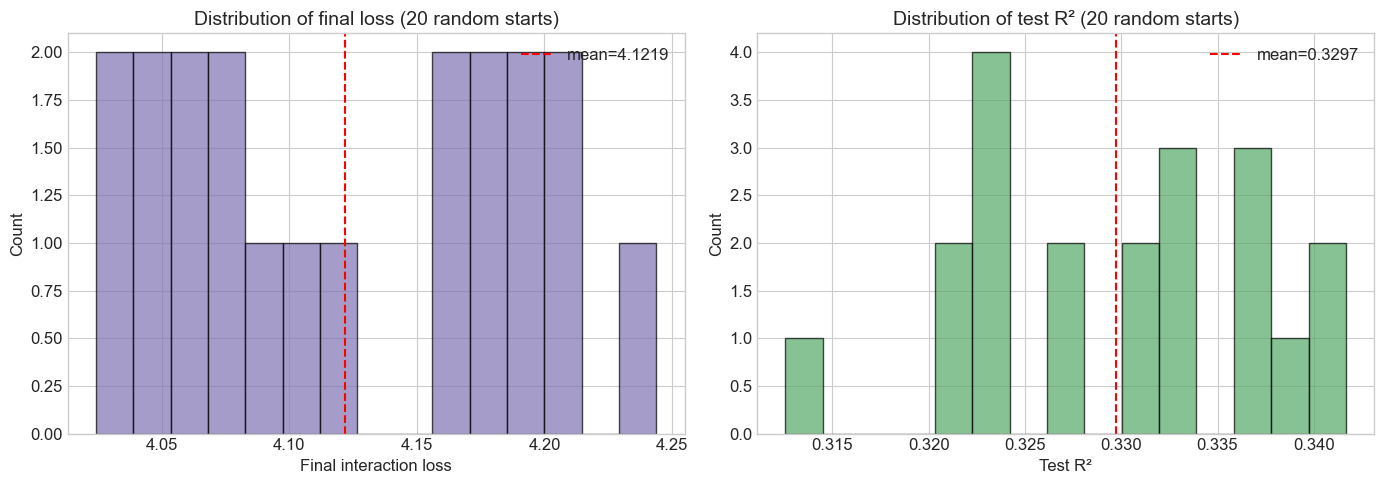


R² range: 0.0291, CV: 0.0231
→ LOW VARIANCE across random starts. All converge to a similar R².
  The information ceiling is real. Supports H2 (information bottleneck).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ms_losses, bins=15, edgecolor="black", alpha=0.7, color="#8172B3")
axes[0].axvline(np.mean(ms_losses), color="red", linestyle="--", label=f"mean={np.mean(ms_losses):.4f}")
axes[0].set_xlabel("Final interaction loss")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of final loss (20 random starts)")
axes[0].legend()

axes[1].hist(ms_r2s, bins=15, edgecolor="black", alpha=0.7, color="#55A868")
axes[1].axvline(np.mean(ms_r2s), color="red", linestyle="--", label=f"mean={np.mean(ms_r2s):.4f}")
axes[1].set_xlabel("Test R²")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of test R² (20 random starts)")
axes[1].legend()

plt.tight_layout()
plt.show()

r2_range = np.max(ms_r2s) - np.min(ms_r2s)
r2_cv = np.std(ms_r2s) / (np.mean(ms_r2s) + 1e-10)
print(f"\nR² range: {r2_range:.4f}, CV: {r2_cv:.4f}")
if r2_range > 0.10 or r2_cv > 0.15:
    print("→ HIGH VARIANCE across random starts. Some find much better solutions.")
    print("  Strong evidence for H1 (optimization bottleneck).")
else:
    print("→ LOW VARIANCE across random starts. All converge to a similar R².")
    print("  The information ceiling is real. Supports H2 (information bottleneck).")

## Summary

| Analysis | Question | H1 indicator | H2 indicator |
|----------|----------|--------------|--------------|
| 1. Oracle→Interaction loss | Can Gamma "see" a better solution? | Oracle loss ≪ Int. loss | Oracle loss ≈ Int. loss |
| 2. Spectral analysis | Is w* encoded in Gamma? | High alignment | Low alignment |
| 3. Spectral init | Does better init help? | Spectral ≫ warm-start | Similar performance |
| 4. Multi-start | Do different starts find different optima? | High R² variance | Low R² variance |

Run this notebook and read the printed interpretations to determine whether the gap to Oracle
is primarily due to **optimization** (H1) or **information** (H2).